# Etapa 04. ¿Por qué importa cuándo llega el agua?


El panel compara dos secuencias con la misma cantidad total de aportes. Un análisis anual las consideraría equivalentes respecto del total de agua. Pero existe almacenamiento limitado y demanda durante todo el horizonte. La memoria y la secuencia pueden cambiar lo que se vierte, lo que se conserva y lo que falta. Este es un mecanismo sistémico que sí podemos demostrar numéricamente sin fingir un modelo nacional.

Partimos del mismo stock inicial y las mismas capacidades. Una secuencia sintética sigue una forma estacional; otra desplaza su calendario. También ensayamos aportes concentrados en pocos meses, conservando el total. El calendario es mensual y sus horas convierten MW a MWh. El agua se representa mediante MWh equivalentes con conversión fija. No proviene de multiplicar el porcentaje histórico por una capacidad arbitraria.

Leemos la tabla como la bañera: stock inicial más aportes, menos generación hidro y vertimiento, igual a stock final. El segundo balance concilia demanda con solar, hidro, térmica y faltante. Comprobar ambos antes de interpretar evita atribuir a la complejidad un error de programación.

La regla base usa primero solar y luego hidro disponible, antes de térmica. Es miope: no valora agua futura. Una reserva operativa modifica esa regla y puede intercambiar uso térmico presente por agua posterior. No existe garantía de mejora en todo escenario. El resultado depende de restricciones, horizonte y secuencia. Si termina con más agua, también debemos reconocer ese estado terminal al comparar costos.

El experimento sugiere preguntas sobre persistencia de sequía y complementariedad temporal. No estima el cambio de ENSO ni convierte faltante mensual en probabilidad de racionamiento. Para Colombia se necesitarían aportes, conversión, restricciones de centrales, disponibilidades y resoluciones temporales pertinentes. La agregación mensual puede ocultar déficit nocturno aunque el mes balancee.

Finalmente ajustamos demanda pico histórica y evaluamos fuera de muestra contra mantener el último valor. Ese es el componente calibrado. Que funcione no valida el almacén ni su regla. La estadística y el modelo de balance aportan evidencias diferentes; integrarlas requiere conservar esa distinción.

**Entrega:** ecuaciones, tabla de parámetros, dos balances y comparación de secuencias. Explica qué cambió con igual aporte total, qué no cambió y qué variable adicional pedirías para evaluar este mecanismo en el SIN.


# Etapa 04 — ¿Por qué importa cuándo llega el agua?

Consulta el dossier. Predice, calcula, explica y juzga el alcance antes de registrar tu decisión.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
# Encuentra la raíz tanto desde la carpeta del notebook como desde la raíz del libro.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'sa_mise' / '__init__.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from sa_mise import datos, modelos, expediente
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})

In [2]:
from sa_mise import sector
CASO='ejemplo_docente'
# Usa el mismo identificador de tu equipo en las ocho etapas.

## 1. Conservemos el agua total y cambiemos su secuencia
Todas las secuencias son sintéticas y empiezan con el mismo stock. La variante concentrada distribuye el aporte total en cuatro meses; es un estrés de mecanismo, no una probabilidad climática.

,secuencia,aportes_MWh_eq,faltante_MWh,vertimiento_MWh_eq,stock_final_MWh_eq
0,Estacional,2160000.0,0.0,3.319125e+05,193687.513879
1,Desplazado 4 meses,2160000.0,0.0,2.856000e+05,240000.000000
2,Concentrado,2160000.0,711456.0,1.514400e+06,0.000000


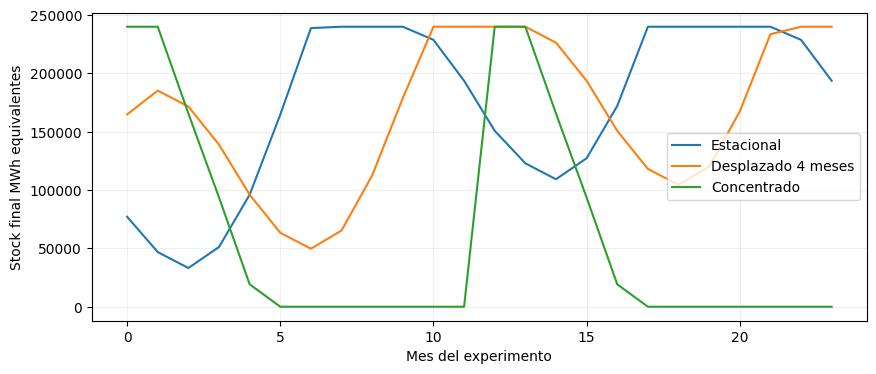

In [3]:
a=sector.aportes_docentes();concentrado=np.zeros(24);concentrado[[0,1,12,13]]=a.sum()/4
secuencias={'Estacional':a,'Desplazado 4 meses':np.roll(a,4),'Concentrado':concentrado}
trayectorias={n:sector.sistema_docente(v) for n,v in secuencias.items()}
for v in secuencias.values():assert np.isclose(v.sum(),a.sum())
filas=[]
for n,d in trayectorias.items():
    assert np.allclose(d.stock_inicial_MWh_eq+d.aporte_MWh_eq-d.hidro_MWh-d.vertimiento_MWh_eq,d.stock_final_MWh_eq)
    assert np.allclose(d.demanda_neta_MWh,d.solar_MWh+d.hidro_MWh+d.termica_MWh+d.faltante_MWh)
    filas.append([n,d.aporte_MWh_eq.sum(),d.faltante_MWh.sum(),d.vertimiento_MWh_eq.sum(),d.stock_final_MWh_eq.iloc[-1]])
display(pd.DataFrame(filas,columns=['secuencia','aportes_MWh_eq','faltante_MWh','vertimiento_MWh_eq','stock_final_MWh_eq']))
for n,d in trayectorias.items():plt.plot(np.arange(24),d.stock_final_MWh_eq,label=n)
plt.xlabel('Mes del experimento');plt.ylabel('Stock final MWh equivalentes');plt.legend();plt.show()

Lee primero la igualdad de aportes y después vertimiento, faltante y stock final. El almacenamiento finito y el orden de llegada explican diferencias posibles. Si dos secuencias no cambian una métrica, también es un resultado: revisa qué restricción estaba activa. No conviertas faltante docente en racionamiento colombiano.

## 2. Una parte sí se contrasta con observaciones
La demanda pico se ajusta hasta 2018 y se prueba después. Comparamos con la referencia de mantener el último valor; ambas utilizan la misma información de entrenamiento.

In [4]:
ajuste,met=datos.estimar_tendencia_demanda();prueba=ajuste[ajuste.particion=='prueba']
ultimo=ajuste[ajuste.particion=='entrenamiento'].demanda_pico_MW.iloc[-1]
display(met)
display(pd.Series({'MAE_tendencia_MW':prueba.error_MW.abs().mean(),'MAE_ultimo_valor_MW':(prueba.demanda_pico_MW-ultimo).abs().mean()}))

{'crecimiento_estimado_anual': 0.015489620991799815,
 'MAE_MW': {'entrenamiento': 157.93392633858065, 'prueba': 175.90461660763626},
 'fin_entrenamiento': 2018}

MAE_tendencia_MW       175.904617
MAE_ultimo_valor_MW    821.441333
dtype: float64

Un mejor error de demanda no valida la regla de embalse ni la inversión. Explica qué parámetro se estimó y qué componentes siguen supuestos. Esta distinción debe aparecer en el informe, junto al mecanismo aprendido.

## Registrar el avance del equipo
Sustituye el campo de decisión por tu razonamiento y conserva el nivel de evidencia. El identificador es el mismo durante todo el caso.

In [5]:
decision_estudiante='POR COMPLETAR'
expediente.registrar(CASO,'dinamica','Comparación con iguales aportes: '+str(filas),'descripcion' if 4 in [0,1] else 'exploracion',
 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
 'Transformaciones, calendario y unidades explícitos en las celdas precedentes',
 'No constituye evaluación completa del SIN; distinguir cada resultado observado de los sintéticos',
 decision_estudiante)

Out[5]: 
{'version': 2,
 'caso': 'ejemplo_docente',
 'etapas': {'evidencia': {'hallazgo': 'Año 2024: generación 83262.923 GWh y pico 11704.365 MW; son magnitudes diferentes',
   'nivel': 'descripcion',
   'fuente': 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
   'transformacion': 'Transformaciones, calendario y unidades explícitos en las celdas precedentes',
   'limite': 'No constituye evaluación completa del SIN; distinguir cada resultado observado de los sintéticos',
   'decision_estudiante': 'POR COMPLETAR'},
  'identidad': {'hallazgo': "Asociaciones mensuales: {'meses': 264, 'correlacion_bruta': -0.3654022452929349, 'correlacion_residual': -0.5459860648178948, 'interpretacion': 'Asociación; controles aditivos no identifican causalidad ni corrigen toda no estacionariedad'}",
   'nivel': 'descripcion',
   'fuente': 'Extractos locales y/o supuestos identificados en DOSSIER y esta etapa',
   'transformacion': 'Transformaciones, calendario y unidades explícit